<a href="https://colab.research.google.com/github/josephinshajan-a11y/bu_banking/blob/main/Electricity_Price_Analysis_SIMPLE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electricity Price Analysis
Nationwide Utilities - Manufacturing Factory


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# Load dataset
df = pd.read_csv('electricity_price_data.csv')

print('\n' + '='*70)
print('ELECTRICITY PRICE COMPONENTS')
print('='*70)
print(df.to_string(index=False))
print('\n' + '-'*70)
print(f'TOTAL: {df["Amount_pKwh"].sum():.2f} p/kWh')
print('-'*70)


ELECTRICITY PRICE COMPONENTS
                Component  Amount_pKwh       Category  Percentage
    Wholesale Electricity        10.20     Base Price          31
       Balancing Services         2.10 System Charges           6
     Transmission Network         2.40 System Charges           7
     Distribution Network         2.40 System Charges           7
Metering & Administration         0.50 Supplier Costs           2
          Supplier Margin         1.50 Supplier Costs           5
     Environmental Policy         0.50 Supplier Costs           2
                  VAT Tax         0.98          Taxes           3
     Peak Load Adjustment         1.60    Adjustments           5
 Risk & Volatility Buffer        10.30    Risk Buffer          32

----------------------------------------------------------------------
TOTAL: 32.48 p/kWh
----------------------------------------------------------------------


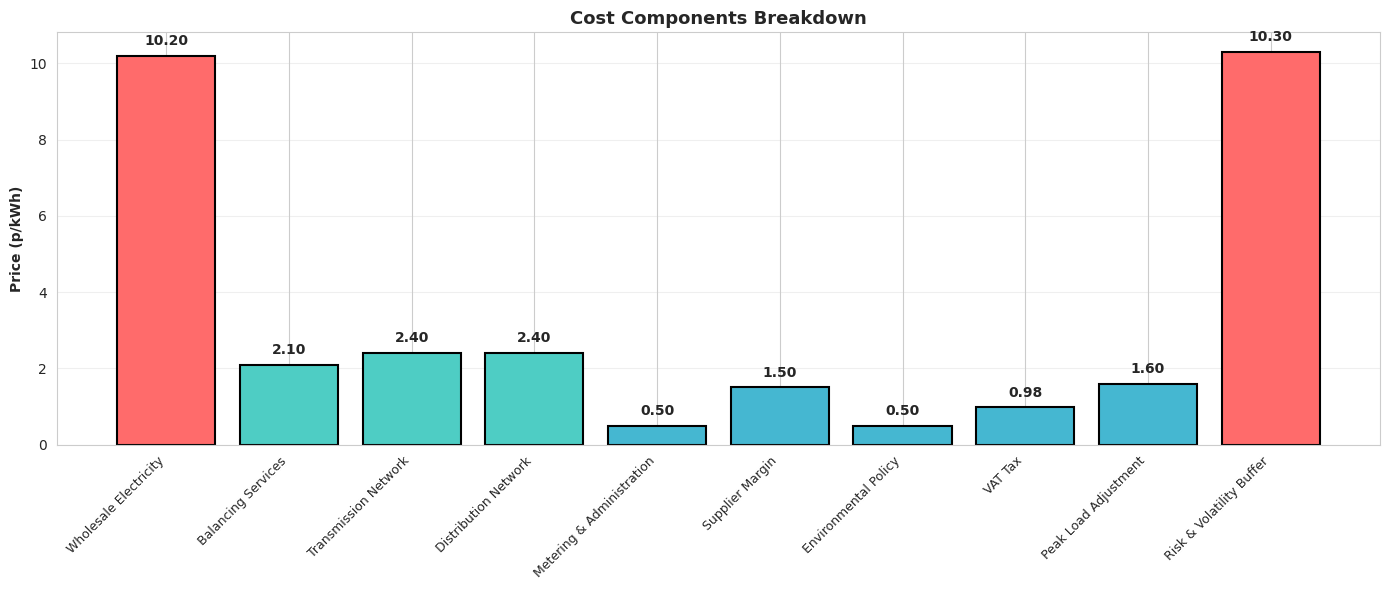

In [3]:
# Chart 1: Cost Breakdown
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#FF6B6B' if x > 5 else '#4ECDC4' if x > 2 else '#45B7D1' for x in df['Amount_pKwh']]
bars = ax.bar(range(len(df)), df['Amount_pKwh'], color=colors, edgecolor='black', linewidth=1.5)

for bar, val in zip(bars, df['Amount_pKwh']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Price (p/kWh)', fontweight='bold')
ax.set_title('Cost Components Breakdown', fontweight='bold', fontsize=13)
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df['Component'], rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

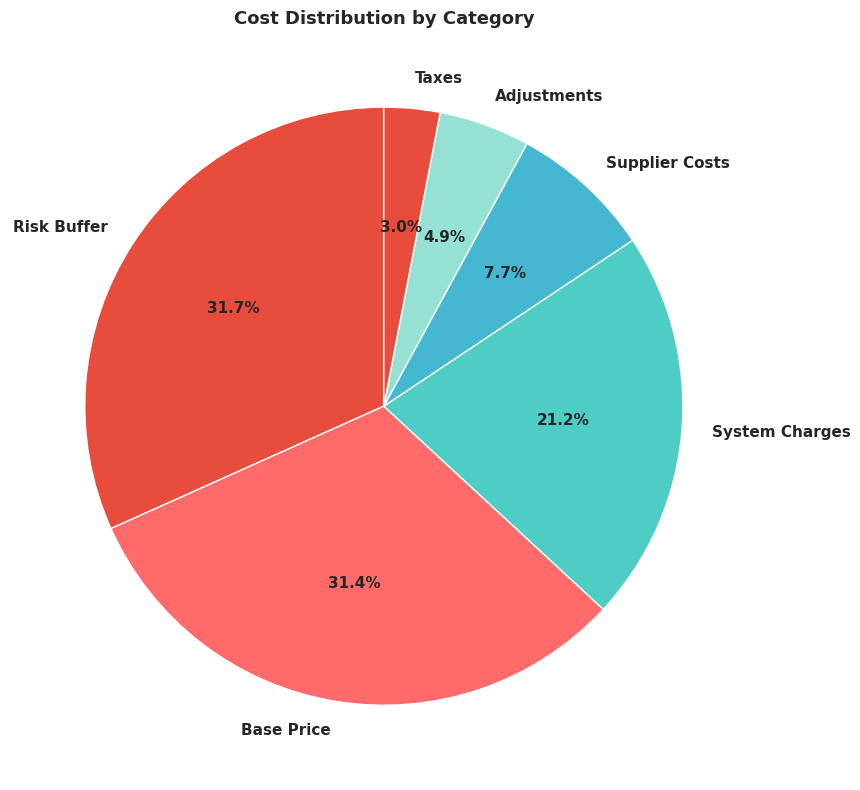

In [4]:
# Chart 2: Distribution by Category
category_totals = df.groupby('Category')['Amount_pKwh'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors_pie = ['#E74C3C', '#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3']
ax.pie(category_totals, labels=category_totals.index, autopct='%1.1f%%',
       colors=colors_pie, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title('Cost Distribution by Category', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

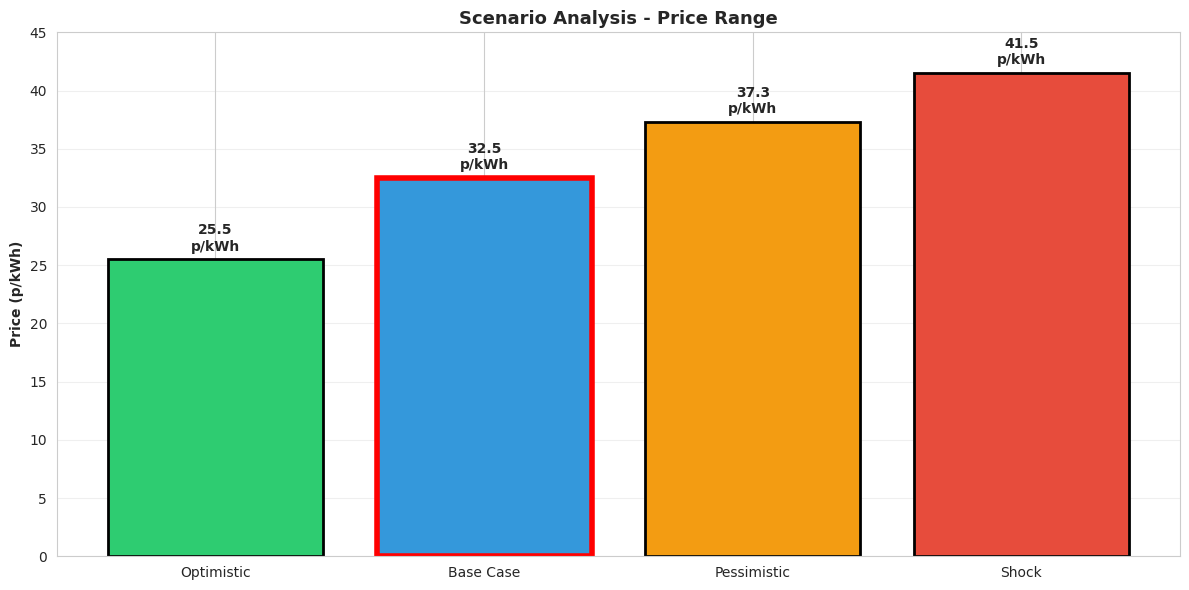

In [5]:
# Chart 3: Scenario Comparison
scenarios = {
    'Optimistic': 25.5,
    'Base Case': 32.5,
    'Pessimistic': 37.3,
    'Shock': 41.5
}

fig, ax = plt.subplots(figsize=(12, 6))
colors_scenario = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
bars = ax.bar(scenarios.keys(), scenarios.values(), color=colors_scenario, edgecolor='black', linewidth=2)

# Highlight base case
bars[1].set_edgecolor('red')
bars[1].set_linewidth(4)

for bar, price in zip(bars, scenarios.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{price:.1f}\np/kWh', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Price (p/kWh)', fontweight='bold')
ax.set_title('Scenario Analysis - Price Range', fontweight='bold', fontsize=13)
ax.set_ylim(0, 45)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Final Answer
print('\n' + '='*70)
print('FINAL ANSWER')
print('='*70)
print(f'\nEstimated Price: {df["Amount_pKwh"].sum():.1f} p/kWh')
print(f'Confidence Level: 65-70%')
print(f'\nPrice Range:')
print(f'  Optimistic:   25.5 p/kWh (15%)')
print(f'  Base Case:    32.5 p/kWh (50%) ← ESTIMATE')
print(f'  Pessimistic:  37.3 p/kWh (25%)')
print(f'  Shock:        41.5 p/kWh (10%)')
print('\n' + '='*70)


FINAL ANSWER

Estimated Price: 32.5 p/kWh
Confidence Level: 65-70%

Price Range:
  Optimistic:   25.5 p/kWh (15%)
  Base Case:    32.5 p/kWh (50%) ← ESTIMATE
  Pessimistic:  37.3 p/kWh (25%)
  Shock:        41.5 p/kWh (10%)



In [7]:
# Methodology Summary
print('\nMETHODOLOGY:')
print('─'*70)
print('\n1. Wholesale Base: 9.8 p/kWh (Q1 2026) + 4% seasonality = 10.2')
print('2. System Charges: 6.9 (BSUoS 2.1 + TNUoS 2.4 + DNUoS 2.4)')
print('3. Supplier Costs: 2.5 (Metering 0.5 + Margin 1.5 + Environmental 0.5)')
print('4. VAT (5%): 0.98')
print('5. Base Cost: 20.6 p/kWh')
print('6. Peak Load Adjustment (+8%): 1.6')
print('7. Risk Buffer (+46%): 10.3')
print('\nFINAL: 32.5 p/kWh')
print('\n' + '─'*70)
print('Data Sources:')
print('  • House of Commons Library (wholesale prices)')
print('  • National Grid (system charges)')
print('  • DNOs (distribution costs)')
print('  • Published tariffs (supplier costs)')
print('  • UK Government (tax & policy)')


METHODOLOGY:
──────────────────────────────────────────────────────────────────────

1. Wholesale Base: 9.8 p/kWh (Q1 2026) + 4% seasonality = 10.2
2. System Charges: 6.9 (BSUoS 2.1 + TNUoS 2.4 + DNUoS 2.4)
3. Supplier Costs: 2.5 (Metering 0.5 + Margin 1.5 + Environmental 0.5)
4. VAT (5%): 0.98
5. Base Cost: 20.6 p/kWh
6. Peak Load Adjustment (+8%): 1.6
7. Risk Buffer (+46%): 10.3

FINAL: 32.5 p/kWh

──────────────────────────────────────────────────────────────────────
Data Sources:
  • House of Commons Library (wholesale prices)
  • National Grid (system charges)
  • DNOs (distribution costs)
  • Published tariffs (supplier costs)
  • UK Government (tax & policy)
